In [7]:
import pandas as pd
import os

# File paths mapped to their trading days
file_day_map = {
    "prices_round_1_day_-2.csv": -2,
    "prices_round_2_day_-1.csv": -1,
    "prices_round_3_day_0.csv": 0,
    "prices_round_4_day_1.csv": 1,
    "prices_round_5_day_2.csv": 2,
    "prices_round_5_day_3.csv": 3,
    "prices_round_5_day_4.csv": 4
}

# It looks like the files were not parsed correctly due to a missing delimiter
# Reload all the files with the correct delimiter

dataframes = []
for filename, day in file_day_map.items():
    filepath = f"data/{filename}"
    df = pd.read_csv(filepath, delimiter=';')
    df["day"] = day
    dataframes.append(df)

# Combine all data into a single DataFrame
all_data = pd.concat(dataframes, ignore_index=True)

# Check the column names now
all_data.columns


Index(['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1',
       'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3',
       'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2',
       'ask_price_3', 'ask_volume_3', 'mid_price', 'profit_and_loss'],
      dtype='object')

In [11]:
filtered_data = all_data[all_data["product"].isin(["KELP", "RAINFOREST_RESIN", "SQUID_INK"])]

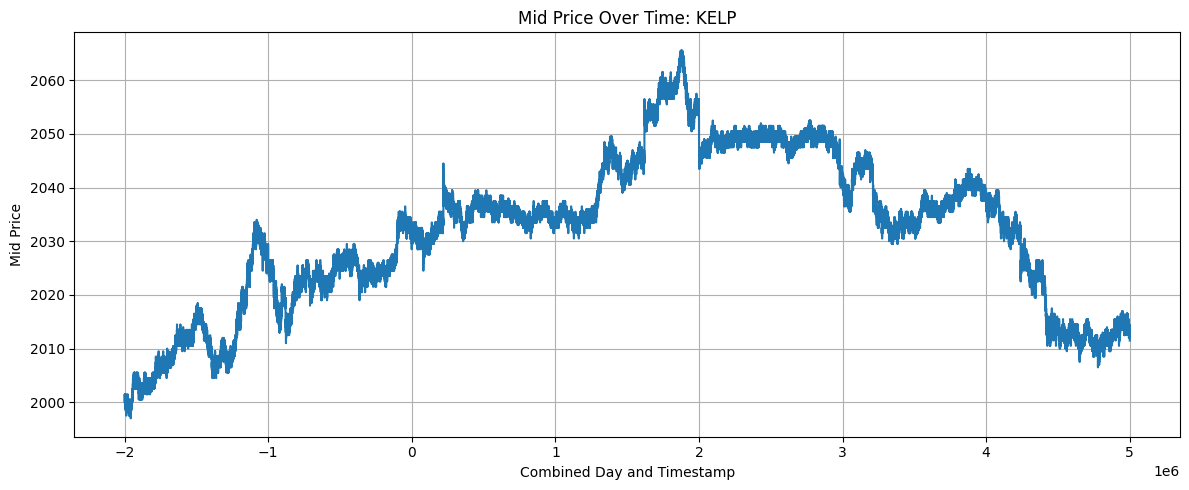

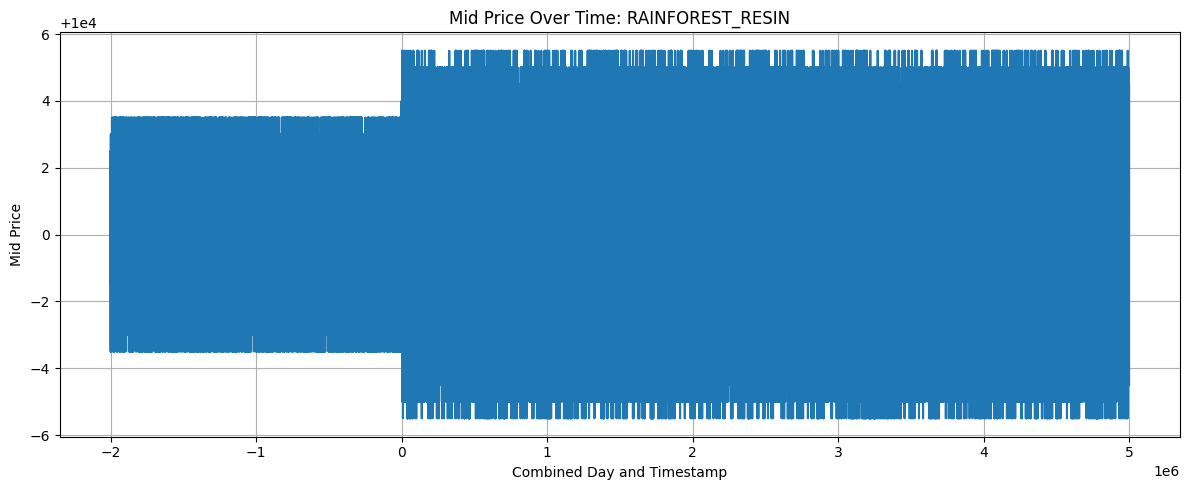

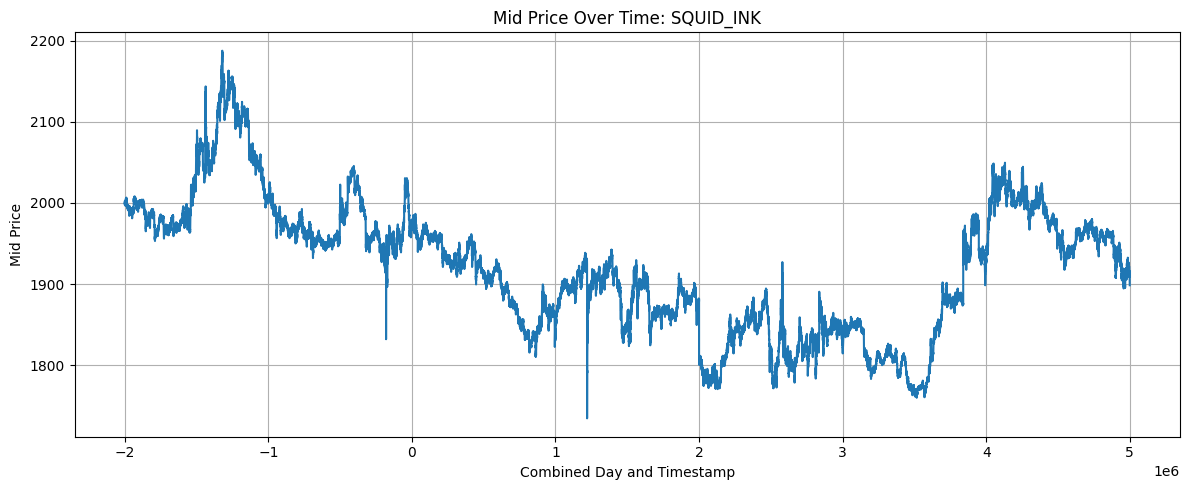

In [12]:
import matplotlib.pyplot as plt

# Function to plot mid price over time for each product
def plot_product_price_trends(data, product_name):
    product_data = data[data["product"] == product_name]
    product_data = product_data.sort_values(by=["day", "timestamp"])
    plt.figure(figsize=(12, 5))
    plt.plot(product_data["day"] * 1000000 + product_data["timestamp"], product_data["mid_price"], label=product_name)
    plt.title(f"Mid Price Over Time: {product_name}")
    plt.xlabel("Combined Day and Timestamp")
    plt.ylabel("Mid Price")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plot for each product
for product in ["KELP", "RAINFOREST_RESIN", "SQUID_INK"]:
    plot_product_price_trends(filtered_data, product)


In [16]:
summary_stats = filtered_data.groupby("product").agg({
    "mid_price": ["mean", "std", "min", "max"],
    "bid_volume_1": "mean",
    "ask_volume_1": "mean"
})

# Flatten multi-index columns
summary_stats.columns = ['_'.join(col).strip() for col in summary_stats.columns.values]
summary_stats.reset_index(inplace=True)
summary_stats


,product,mid_price_mean,mid_price_std,mid_price_min,mid_price_max,bid_volume_1_mean,ask_volume_1_mean
0,KELP,2031.817479,14.285742,1997.0,2065.5,21.183186,20.230629
1,RAINFOREST_RESIN,10000.005843,2.010923,9994.5,10005.5,20.742729,20.803643
2,SQUID_INK,1920.883143,81.045695,1734.5,2187.5,21.279829,20.395071


KELP
Mean Price: 2031.82

Volatility (std): 14.29 → Low

Liquidity: High (avg bid vol ~21.2, ask vol ~20.2)

📈 Strategy Suggestion:

Mean Reversion Market Making: Price range is narrow and volatility is low. Deploy a tight-spread market making strategy with inventory rebalancing near the mean (~2032).

Set limit orders around ±10 from mean.

Recenter often, use moving average as fair value.

🌿 RAINFOREST_RESIN
Mean Price: 10000.01

Volatility (std): 2.01 → Very Low

Liquidity: High and symmetrical (avg bid/ask vol ~20.7)

📈 Strategy Suggestion:

Aggressive Market Making: Ultra-stable price makes this a perfect candidate for small-tick profit scalping.

Quote inside best bid/ask with large size, frequently adjust quotes to maintain top-of-book presence.

🦑 SQUID_INK
Mean Price: 1920.88

Volatility (std): 81.05 → High

Liquidity: High (bid ~21.3, ask ~20.4)

📈 Strategy Suggestion:

Momentum + Volatility-Based Making: Due to large price swings, a pure market making strategy is risky.

Use short-term momentum indicators (e.g., EMA cross or RSI) to dynamically adjust bid-ask spreads.

Widen spreads in high-volatility periods. Hold inventory limits tighter.


In [ ]:
import numpy as np

# Sort filtered data for easier time series analysis
filtered_data = filtered_data.sort_values(by=["product", "day", "timestamp"]).reset_index(drop=True)

# Create signal columns
filtered_data["fair_value"] = np.nan
filtered_data["spread"] = np.nan
filtered_data["signal"] = ""


def generate_signals(df):
    product = df["product"].iloc[0]
    df = df.copy()

    if product == "KELP":
        # Mean reversion: calculate a rolling mean
        df["fair_value"] = df["mid_price"].rolling(window=100, min_periods=1).mean()
        df["spread"] = 3  # fixed spread window
        df["signal"] = np.where(df["mid_price"] < df["fair_value"] - df["spread"], "BUY",
                                np.where(df["mid_price"] > df["fair_value"] + df["spread"], "SELL", "HOLD"))

    elif product == "RAINFOREST_RESIN":
        # Aggressive market making: stable prices, trade around exact fair value
        df["fair_value"] = df["mid_price"].rolling(window=50, min_periods=1).mean()
        df["spread"] = 1  # very tight spread
        df["signal"] = np.where(df["mid_price"] < df["fair_value"] - df["spread"], "BUY",
                                np.where(df["mid_price"] > df["fair_value"] + df["spread"], "SELL", "HOLD"))

    elif product == "SQUID_INK":
        # Volatility-based strategy with momentum
        df["short_ma"] = df["mid_price"].rolling(window=20, min_periods=1).mean()
        df["long_ma"] = df["mid_price"].rolling(window=100, min_periods=1).mean()
        df["fair_value"] = df["long_ma"]
        df["spread"] = df["mid_price"].rolling(window=50, min_periods=1).std().fillna(0)

        df["signal"] = np.where(df["short_ma"] > df["long_ma"] + df["spread"], "BUY",
                                np.where(df["short_ma"] < df["long_ma"] - df["spread"], "SELL", "HOLD"))

    return df


# Apply signal generation per product
signal_data = filtered_data.groupby("product").apply(generate_signals).reset_index(drop=True)

# Display the result with relevant columns
signal_preview = signal_data[["day", "timestamp", "product", "mid_price", "fair_value", "spread", "signal"]]

/var/folders/s8/c86_vmt5617237s9c3g4h75r0000gn/T/ipykernel_28278/3317137486.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  signal_data = filtered_data.groupby("product").apply(generate_signals).reset_index(drop=True)


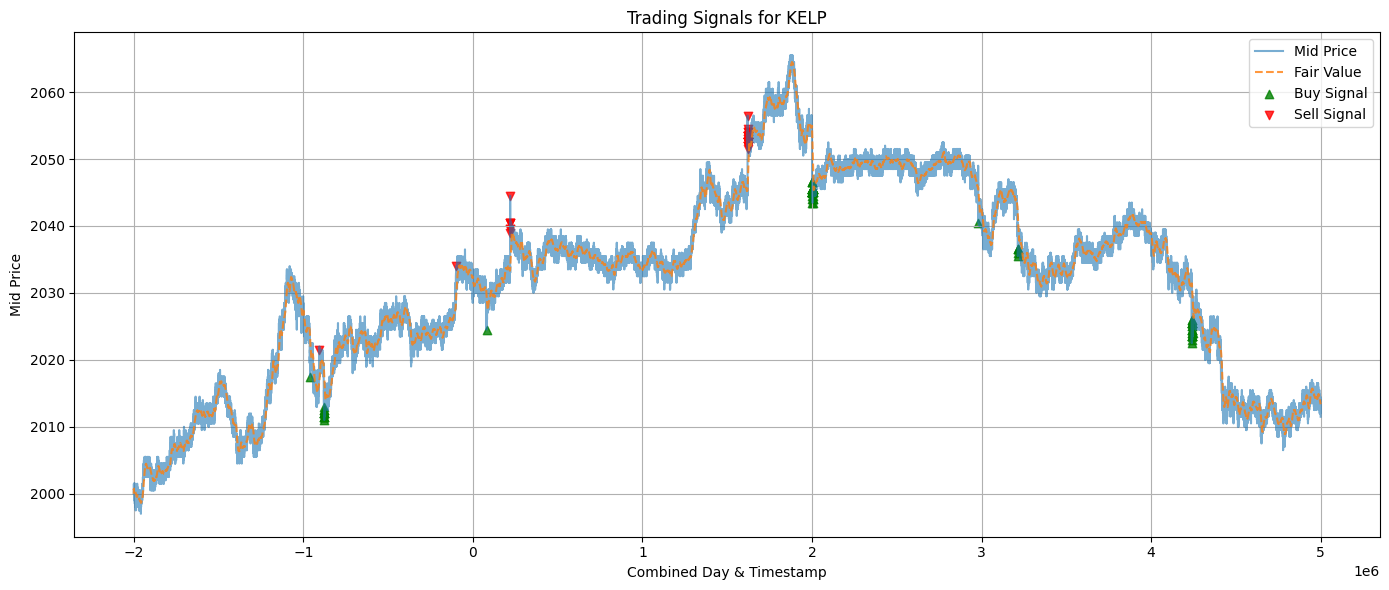

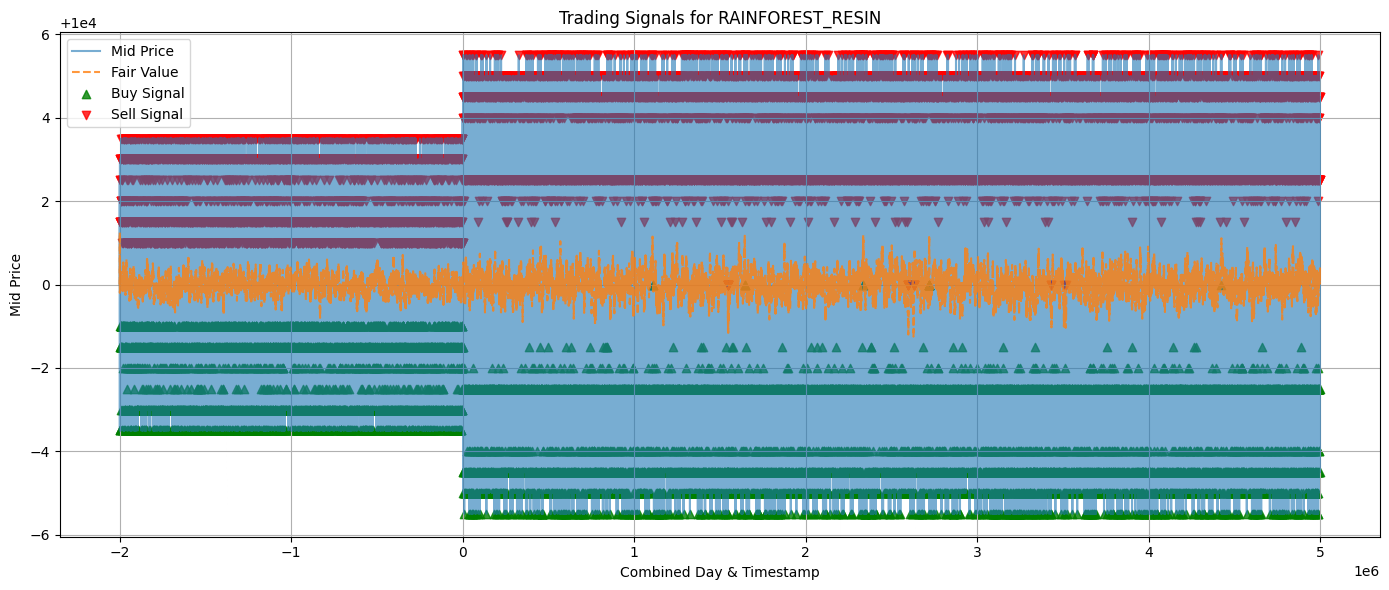

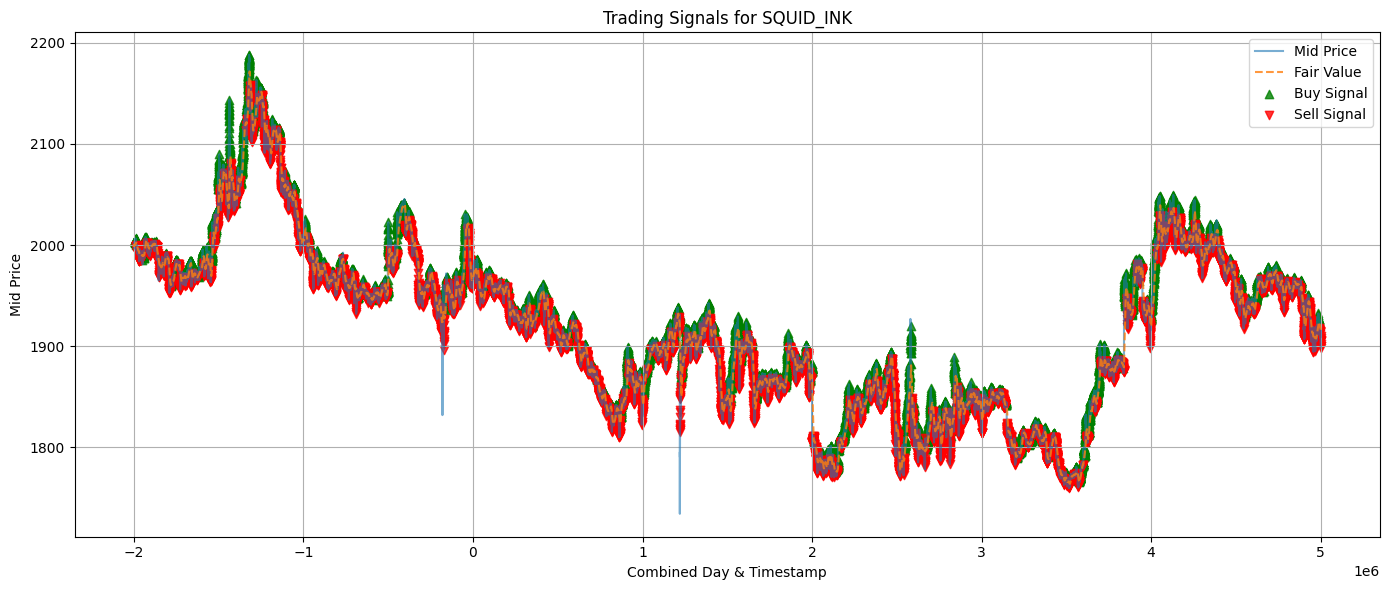

In [20]:
# Plot function for visualizing price and signals
def plot_signals(df, product):
    product_data = df[df["product"] == product].copy()
    product_data["time"] = product_data["day"] * 1_000_000 + product_data["timestamp"]

    plt.figure(figsize=(14, 6))
    plt.plot(product_data["time"], product_data["mid_price"], label="Mid Price", alpha=0.6)
    plt.plot(product_data["time"], product_data["fair_value"], label="Fair Value", linestyle='--', alpha=0.8)

    buy_signals = product_data[product_data["signal"] == "BUY"]
    sell_signals = product_data[product_data["signal"] == "SELL"]

    plt.scatter(buy_signals["time"], buy_signals["mid_price"], marker="^", color="green", label="Buy Signal", alpha=0.8)
    plt.scatter(sell_signals["time"], sell_signals["mid_price"], marker="v", color="red", label="Sell Signal", alpha=0.8)

    plt.title(f"Trading Signals for {product}")
    plt.xlabel("Combined Day & Timestamp")
    plt.ylabel("Mid Price")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Generate plots for each product
for product in ["KELP", "RAINFOREST_RESIN", "SQUID_INK"]:
    plot_signals(signal_data, product)
